# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/algozee/smartphone-addiction-prediction-data/Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/algozee/smartphone-addiction-prediction-data/Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


## last Five row

In [4]:
df.tail()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1
7499,TXN07500,U07500,27,Female,10.04,5.40,0.73,5.45,5.58,215,38,12.17,Low,Yes,Severe,1


## Shape of our dataset

In [5]:
df.shape

(7500, 16)

## List out all columns

In [6]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

## Check Null Value

In [9]:
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

## Drop Addicted Level Feature

In [10]:
df.drop(columns=['addiction_level'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

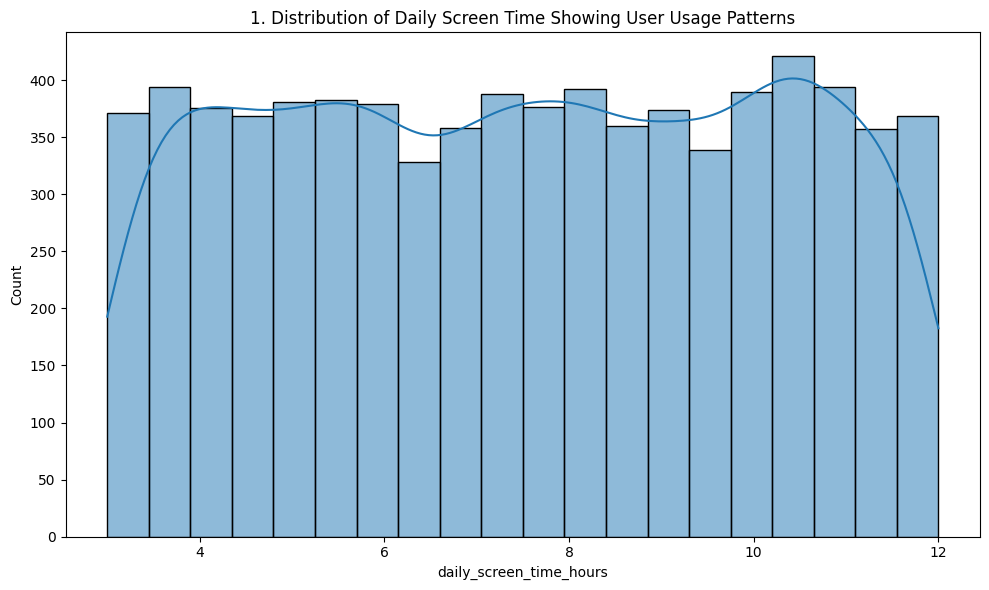

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['daily_screen_time_hours'], kde=True)
plt.title(f'{plot_no}. Distribution of Daily Screen Time Showing User Usage Patterns')
show_fig()
plot_no += 1

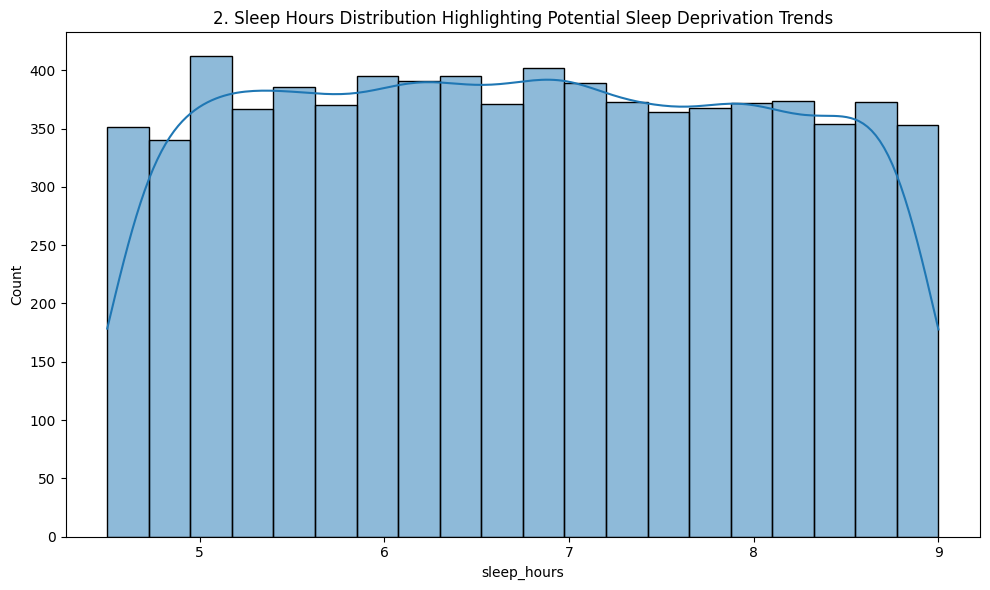

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['sleep_hours'], kde=True)
plt.title(f'{plot_no}. Sleep Hours Distribution Highlighting Potential Sleep Deprivation Trends')
show_fig()
plot_no += 1

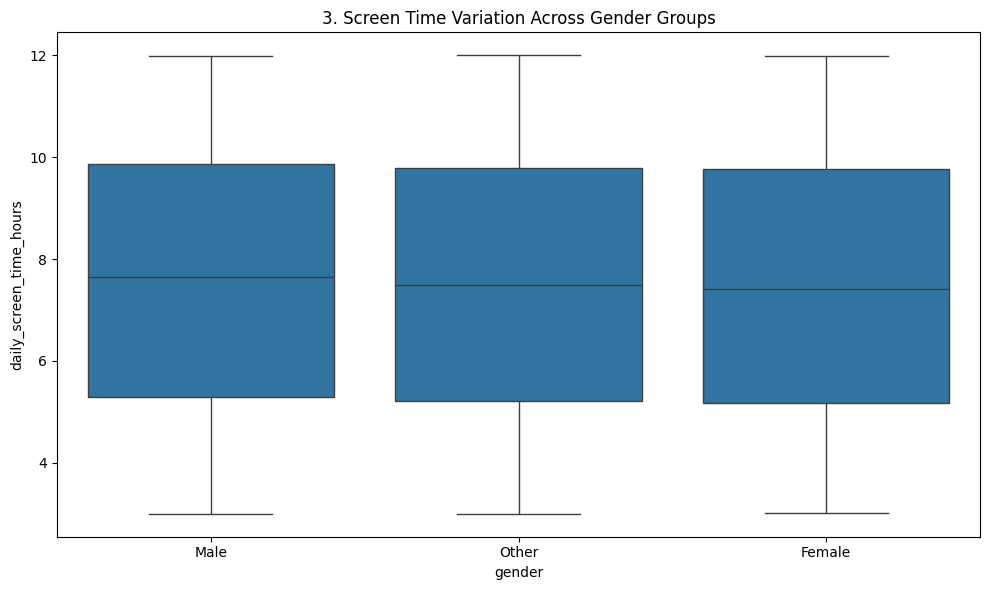

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='daily_screen_time_hours', data=df)
plt.title(f'{plot_no}. Screen Time Variation Across Gender Groups')
show_fig()
plot_no += 1

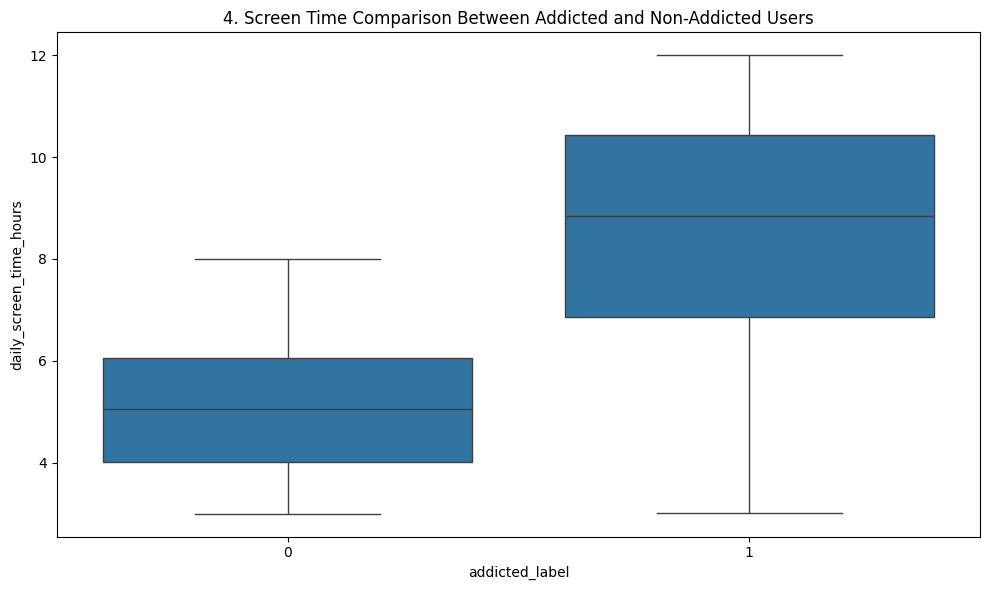

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='addicted_label', y='daily_screen_time_hours', data=df)
plt.title(f'{plot_no}. Screen Time Comparison Between Addicted and Non-Addicted Users')
show_fig()
plot_no += 1

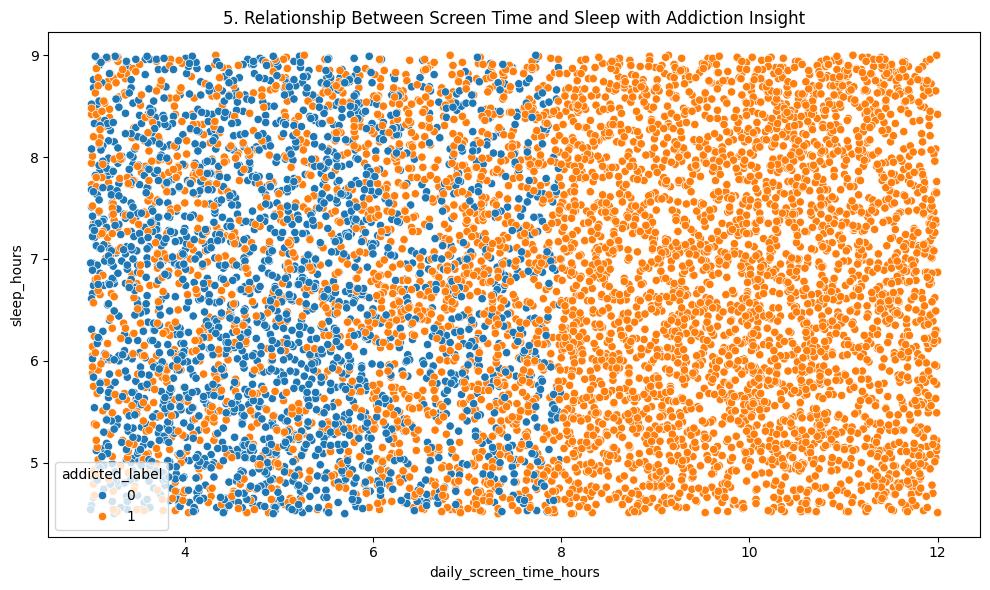

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='daily_screen_time_hours', y='sleep_hours', hue='addicted_label', data=df)
plt.title(f'{plot_no}. Relationship Between Screen Time and Sleep with Addiction Insight')
show_fig()
plot_no += 1

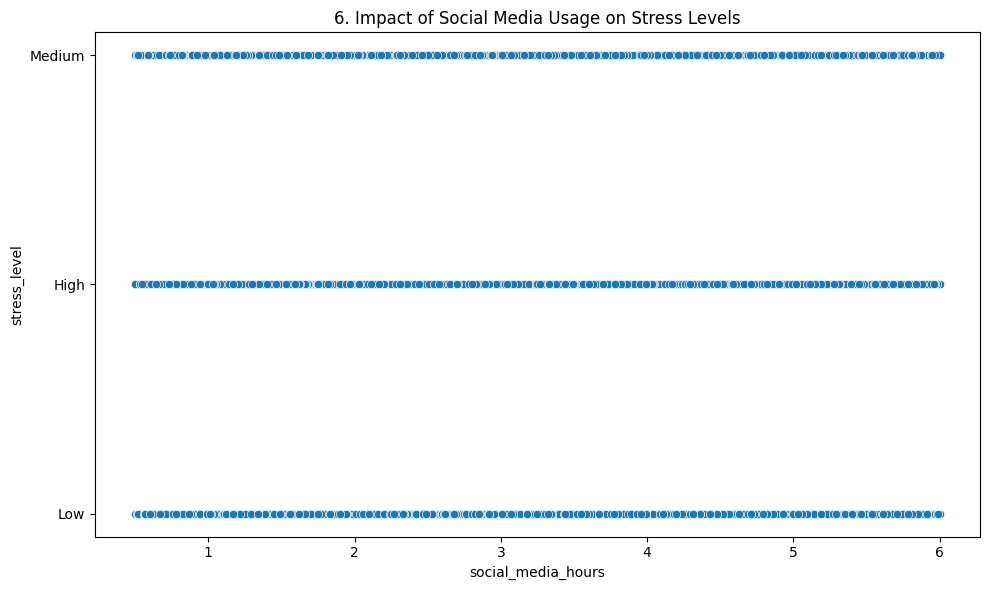

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='social_media_hours', y='stress_level', data=df)
plt.title(f'{plot_no}. Impact of Social Media Usage on Stress Levels')
show_fig()
plot_no += 1

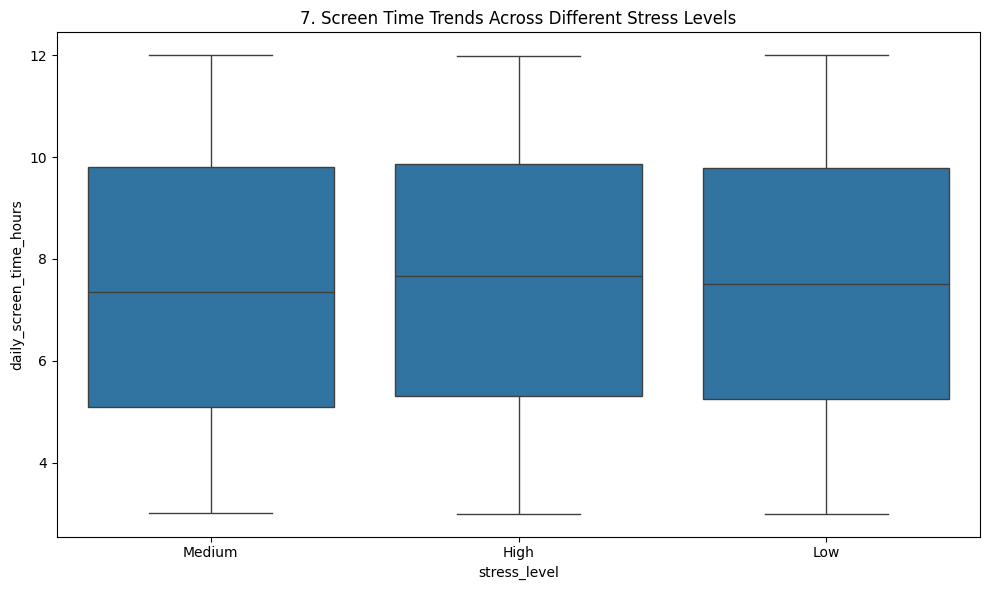

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='stress_level', y='daily_screen_time_hours', data=df)
plt.title(f'{plot_no}. Screen Time Trends Across Different Stress Levels')
show_fig()
plot_no += 1

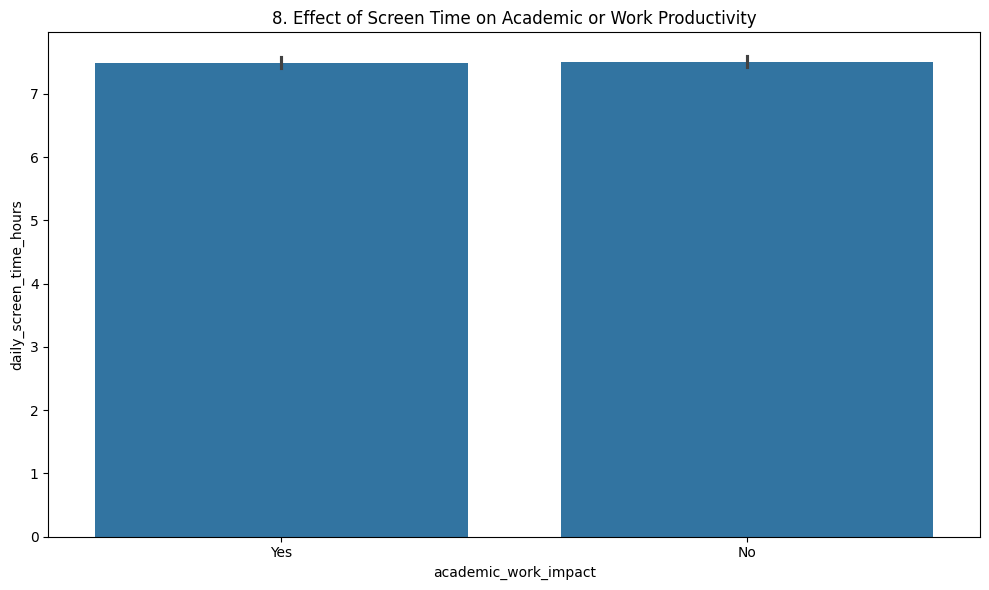

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='academic_work_impact', y='daily_screen_time_hours', data=df)
plt.title(f'{plot_no}. Effect of Screen Time on Academic or Work Productivity')
show_fig()
plot_no += 1

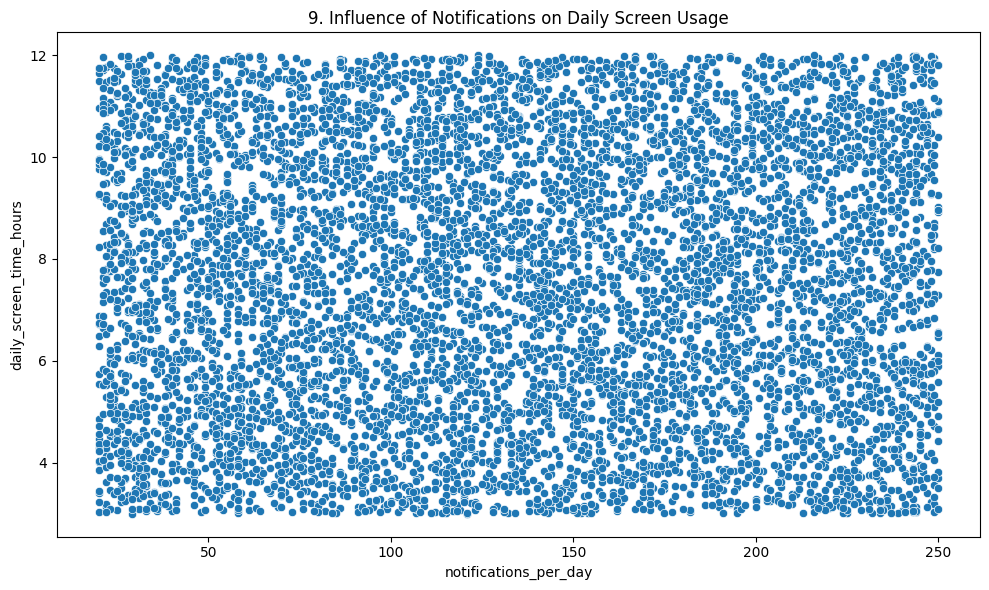

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='notifications_per_day', y='daily_screen_time_hours', data=df)
plt.title(f'{plot_no}. Influence of Notifications on Daily Screen Usage')
show_fig()
plot_no += 1

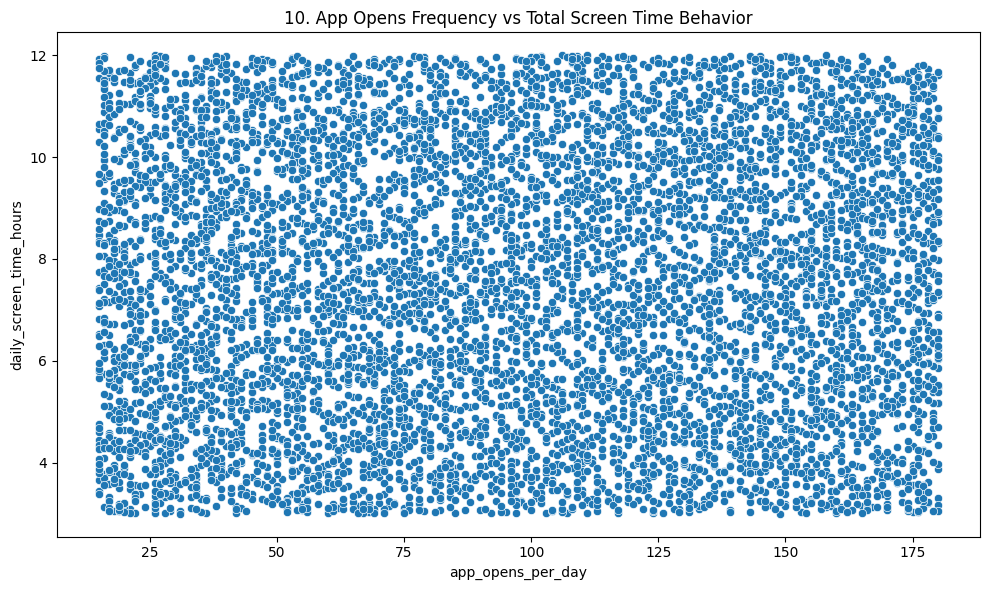

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='app_opens_per_day', y='daily_screen_time_hours', data=df)
plt.title(f'{plot_no}. App Opens Frequency vs Total Screen Time Behavior')
show_fig()
plot_no += 1

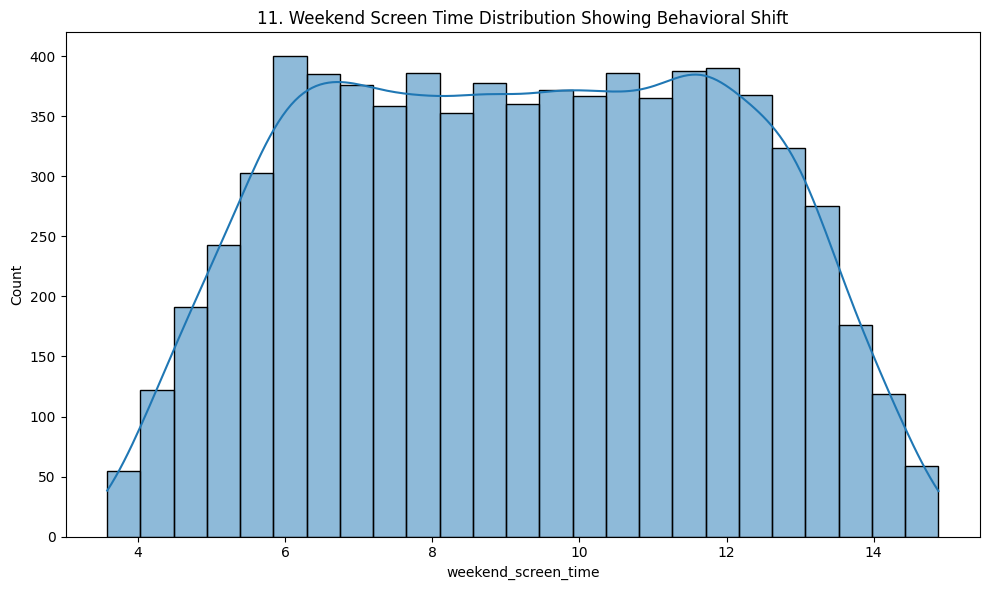

In [24]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['weekend_screen_time'], kde=True)
plt.title(f'{plot_no}. Weekend Screen Time Distribution Showing Behavioral Shift')
show_fig()
plot_no += 1

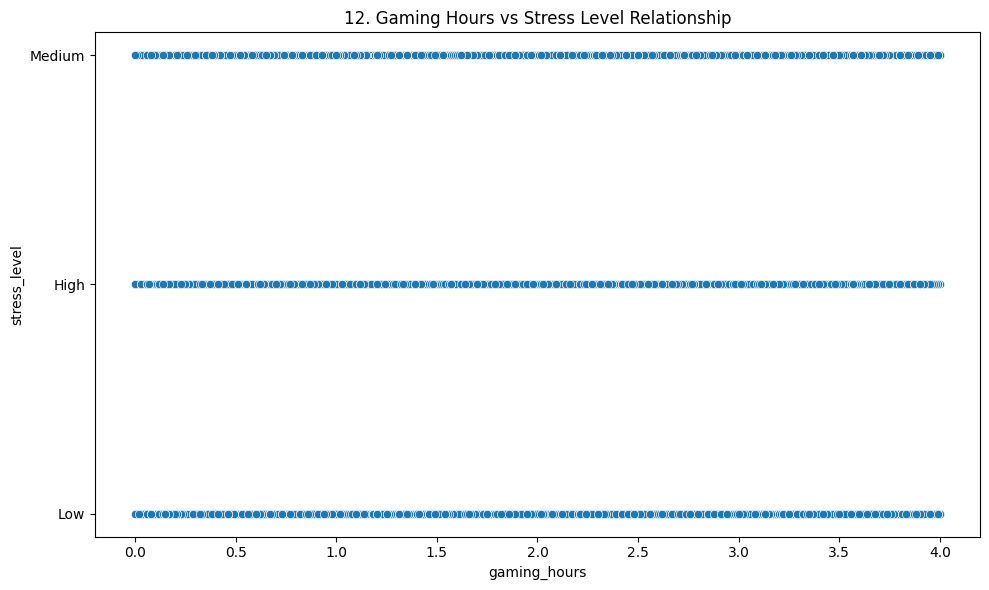

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='gaming_hours', y='stress_level', data=df)
plt.title(f'{plot_no}. Gaming Hours vs Stress Level Relationship')
show_fig()
plot_no += 1

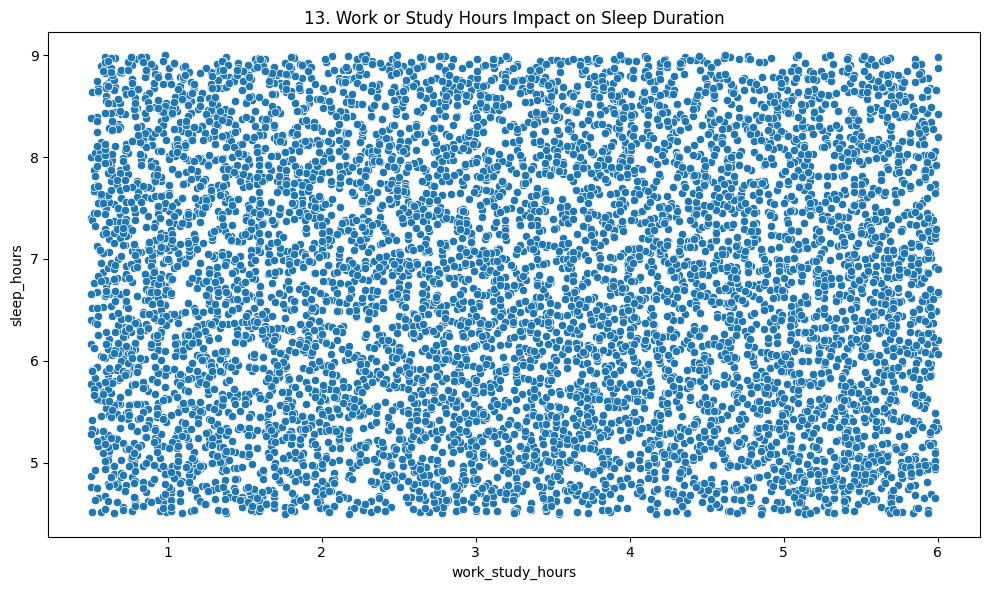

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='work_study_hours', y='sleep_hours', data=df)
plt.title(f'{plot_no}. Work or Study Hours Impact on Sleep Duration')
show_fig()
plot_no += 1

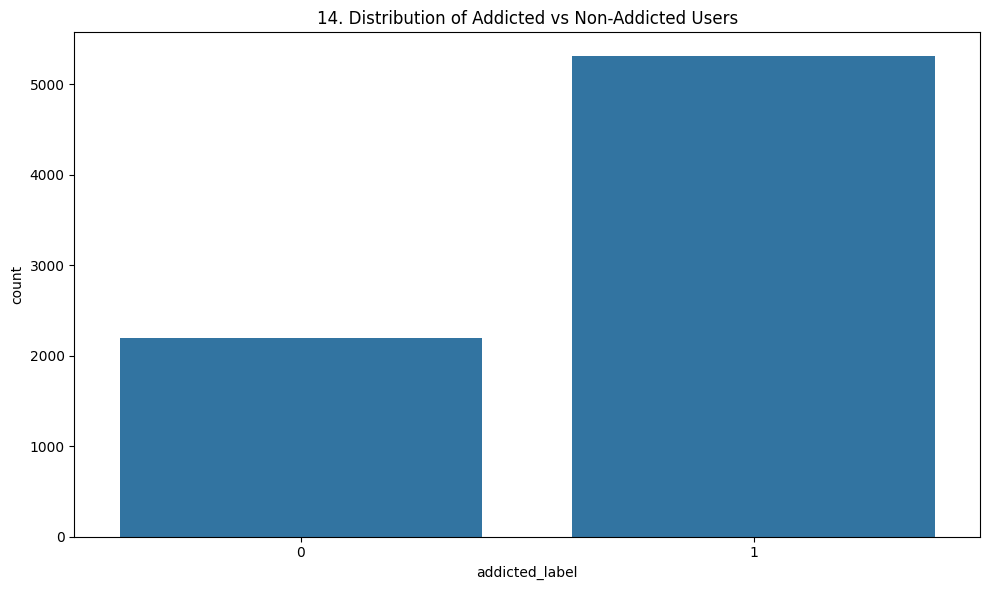

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='addicted_label', data=df)
plt.title(f'{plot_no}. Distribution of Addicted vs Non-Addicted Users')
show_fig()
plot_no += 1

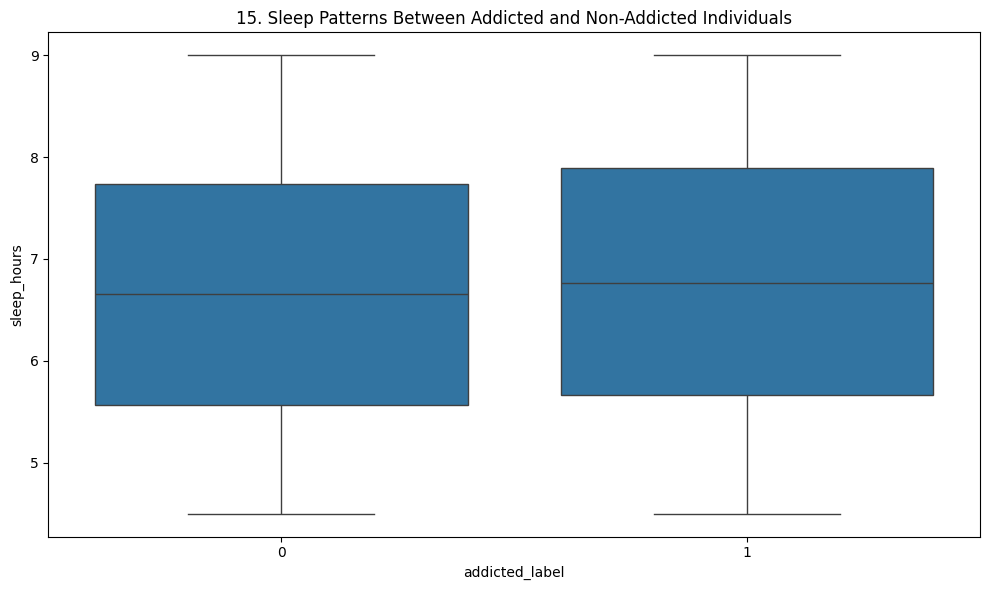

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='addicted_label', y='sleep_hours', data=df)
plt.title(f'{plot_no}. Sleep Patterns Between Addicted and Non-Addicted Individuals')
show_fig()
plot_no += 1

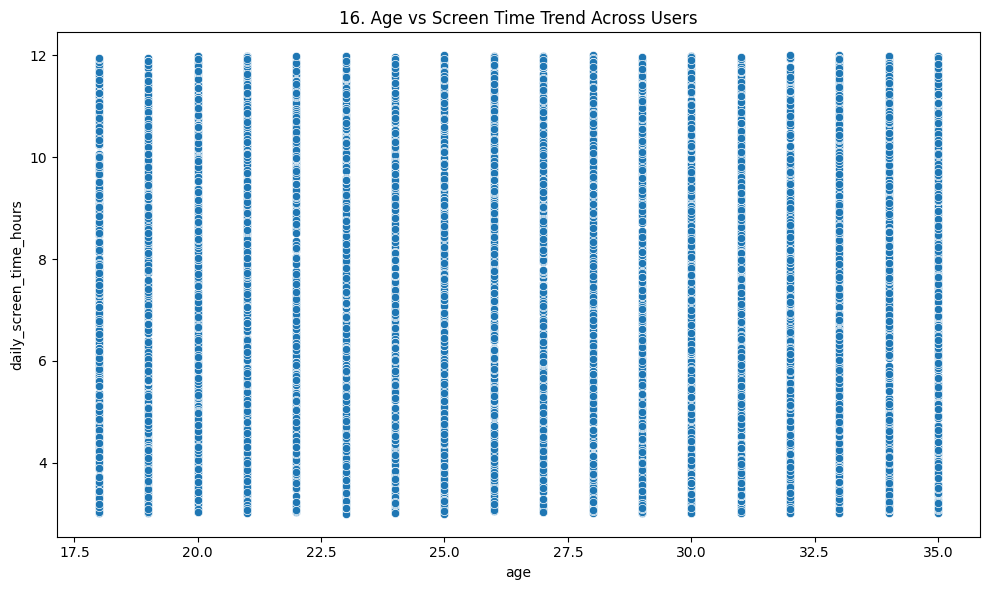

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='daily_screen_time_hours', data=df)
plt.title(f'{plot_no}. Age vs Screen Time Trend Across Users')
show_fig()
plot_no += 1

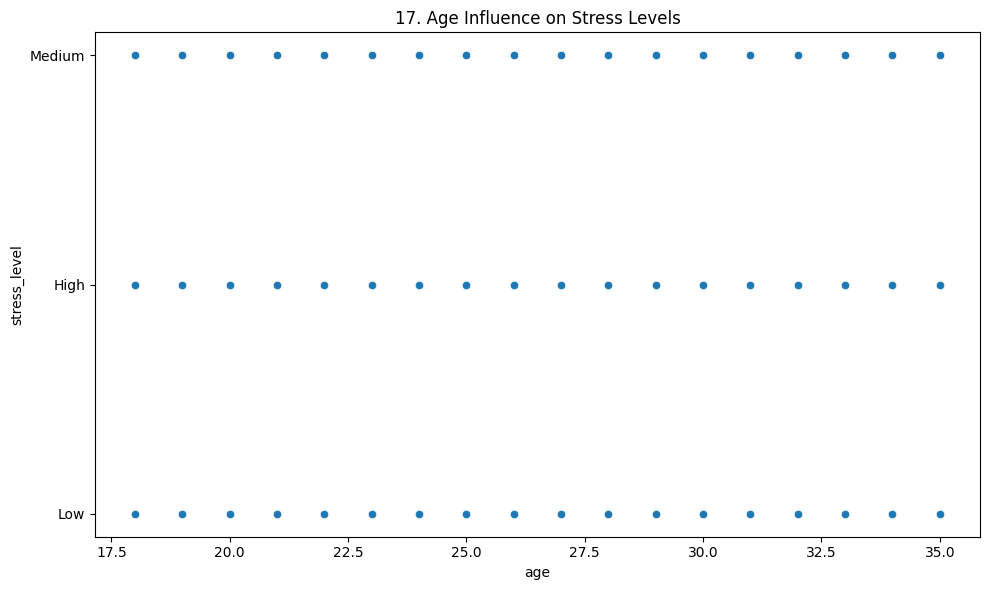

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='stress_level', data=df)
plt.title(f'{plot_no}. Age Influence on Stress Levels')
show_fig()
plot_no += 1

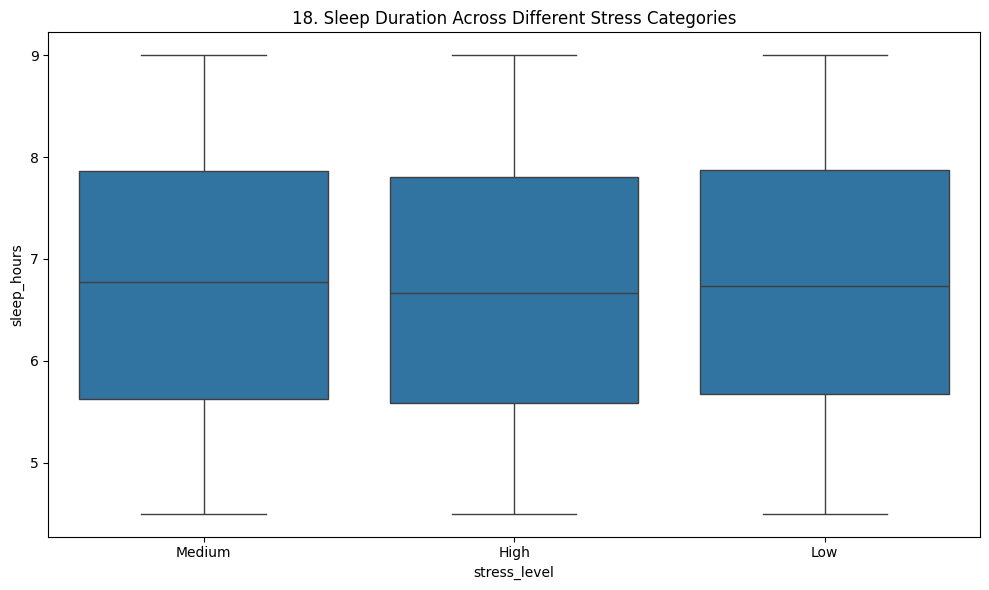

In [31]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='stress_level', y='sleep_hours', data=df)
plt.title(f'{plot_no}. Sleep Duration Across Different Stress Categories')
show_fig()
plot_no += 1

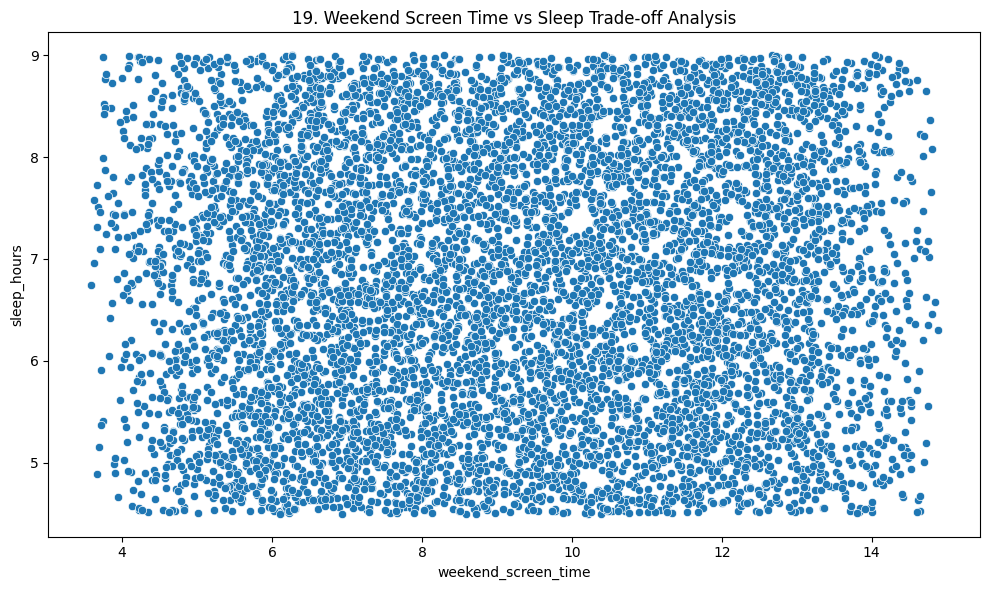

In [32]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='weekend_screen_time', y='sleep_hours', data=df)
plt.title(f'{plot_no}. Weekend Screen Time vs Sleep Trade-off Analysis')
show_fig()
plot_no += 1

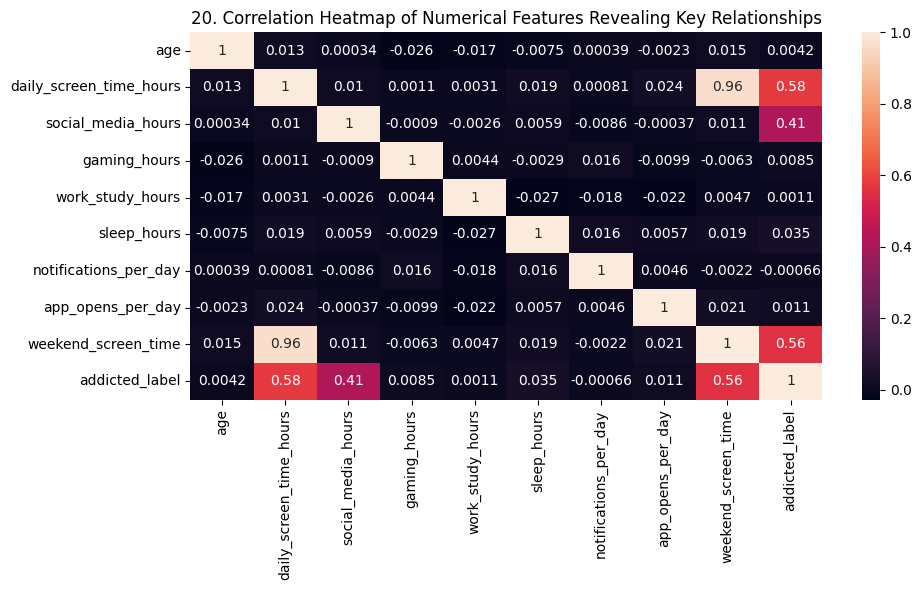

In [33]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features Revealing Key Relationships')
show_fig()
plot_no += 1

# Model Training

## copy dataset

In [34]:
data = df.copy()

## encode categorical columns

In [35]:
le_gender = LabelEncoder()
le_stress = LabelEncoder()
le_academic = LabelEncoder()

data['gender'] = le_gender.fit_transform(data['gender'])
data['stress_level'] = le_stress.fit_transform(data['stress_level'])
data['academic_work_impact'] = le_academic.fit_transform(data['academic_work_impact'])

## drop unnecessary columns

In [36]:
data = data.drop(['transaction_id', 'user_id'], axis=1)

## define features and target

In [37]:
X = data.drop('addicted_label', axis=1)
y = data['addicted_label']

## split dataset

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply scaling

In [39]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train model (Logistic Regression)

In [40]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## predictions

In [41]:
y_pred = model.predict(X_test)

## accuracy score

In [42]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8926666666666667


## confusion matrix plot

<Figure size 1000x600 with 0 Axes>

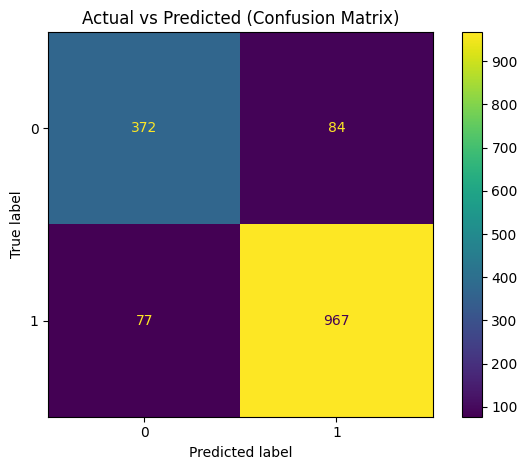

In [43]:
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Actual vs Predicted (Confusion Matrix)')
show_fig()